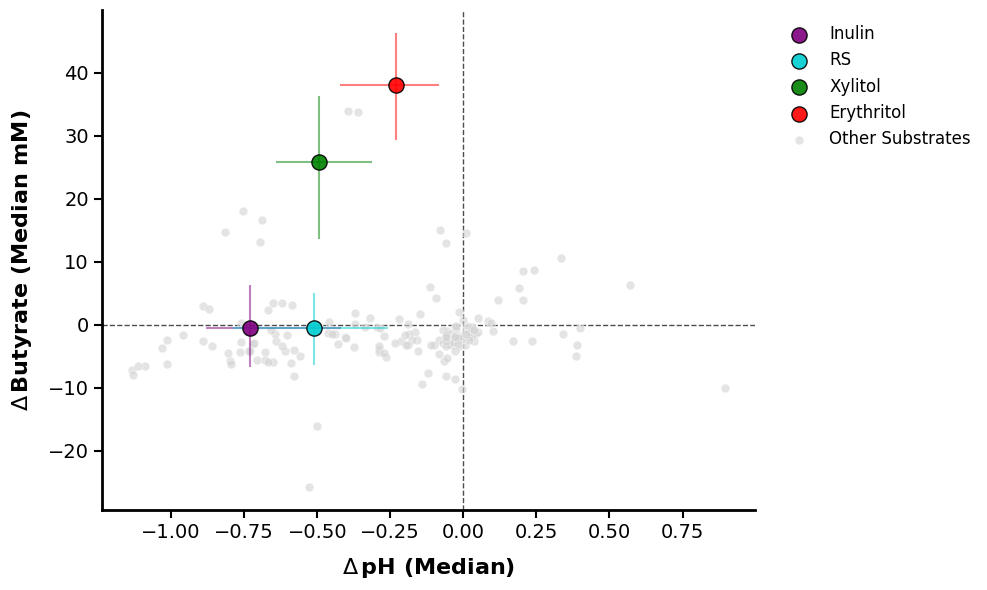

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# =============================================================================
# 1. Publication-Quality Visualization Settings (Nature Portfolio)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

# =============================================================================
# 2. Robust Data Loading & Strict Exclusion Rules
# =============================================================================
def clean_and_convert_to_nan(df, cols):
    """
    Strictly converts non-numeric values (e.g., 'Undetermined', '-', 'nan') to np.nan.
    Zero-imputation is completely avoided.
    """
    for col in cols:
        df[col] = df[col].astype(str).replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Load raw datasets
df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')

donor_cols = [c for c in df_ph.columns if c.startswith('HS-')]

df_ph = clean_and_convert_to_nan(df_ph, donor_cols)
df_buty = clean_and_convert_to_nan(df_buty, donor_cols)

# =============================================================================
# 3. Calculate Delta and Aggregate (Median & IQR) per Substrate
# =============================================================================
ctrl_ph = df_ph[df_ph['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]
ctrl_buty = df_buty[df_buty['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]

aggregated_data = []

for idx, row in df_ph.iterrows():
    kulffi = str(row['KULFFI']).strip()
    if kulffi == 'Control':
        continue

    sub_ph = row[donor_cols]
    buty_rows = df_buty[df_buty['KULFFI'].str.strip() == kulffi]

    if buty_rows.empty:
        continue

    sub_buty = buty_rows[donor_cols].iloc[0]

    delta_ph = sub_ph - ctrl_ph
    delta_buty = sub_buty - ctrl_buty

    # Pairwise exclusion
    valid_mask = pd.notna(delta_ph) & pd.notna(delta_buty)
    valid_delta_ph = delta_ph[valid_mask]
    valid_delta_buty = delta_buty[valid_mask]

    # Calculate non-parametric statistics (Median/IQR)
    if len(valid_delta_ph) > 0:
        aggregated_data.append({
            'KULFFI': kulffi,
            'n_valid': len(valid_delta_ph),
            'ph_med': valid_delta_ph.median(),
            'ph_q25': valid_delta_ph.quantile(0.25),
            'ph_q75': valid_delta_ph.quantile(0.75),
            'buty_med': valid_delta_buty.median(),
            'buty_q25': valid_delta_buty.quantile(0.25),
            'buty_q75': valid_delta_buty.quantile(0.75)
        })

df_agg = pd.DataFrame(aggregated_data)

# =============================================================================
# 4. Plotting Macroscopic Median Landscape
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

target_substrates = ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']

display_names = {
    'Inulin': 'Inulin',
    'Resistant starch': 'RS',
    'Xylitol': 'Xylitol',
    'Erythritol': 'Erythritol'
}

# Colors perfectly synchronized with @5a.ipynb base_colors
highlights = {
    'Inulin': '#800080',             # Purple
    'Resistant starch': '#00CED1',   # Turquoise
    'Xylitol': '#008000',            # Green
    'Erythritol': '#FF0000'          # Red
}

# 1. Target Substrates FIRST
for name, color in highlights.items():
    df_target = df_agg[df_agg['KULFFI'] == name]
    if not df_target.empty:
        x = df_target['ph_med'].values[0]
        y = df_target['buty_med'].values[0]
        xerr = [[x - df_target['ph_q25'].values[0]], [df_target['ph_q75'].values[0] - x]]
        yerr = [[y - df_target['buty_q25'].values[0]], [df_target['buty_q75'].values[0] - y]]

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', ecolor=color, alpha=0.5, capsize=0, zorder=2)
        ax.scatter(x, y, color=color, alpha=0.9, s=120, edgecolors='black', linewidth=1.0, label=display_names[name], zorder=3)

# 2. Other Substrates LAST
df_other = df_agg[~df_agg['KULFFI'].isin(target_substrates)]
ax.scatter(df_other['ph_med'], df_other['buty_med'],
           color='lightgray', alpha=0.6, s=40, edgecolors='white', linewidth=0.5, label='Other Substrates', zorder=1)

# Reference Lines
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)

# LaTeX thin space '\,' applied securely inside math mode
ax.set_xlabel(r'$\Delta\,$pH (Median)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\Delta\,$Butyrate (Median mM)', fontsize=16, fontweight='bold', labelpad=10)

ax.tick_params(axis='both', labelsize=14, width=1.5, length=6)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()

# Export
output_file = 'Figure_6d.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')
plt.show()